In [1]:
import os
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

## 1. Основні налаштування

In [2]:
num_classes = 4
img_size = 224
batch_size = 32

train_data_dir = r'train2'
validation_data_dir = r'test2'

epochs_head = 5          # тільки новий "класифікатор"
epochs_finetune = 10     # fine-tuning бази

## 2. Генератори даних

In [3]:
# Аугментація для навчання
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    shear_range=0.3,
    zoom_range=0.3,
    width_shift_range=0.4,
    height_shift_range=0.4,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_size, img_size),
    color_mode='rgb',          # grayscale зображення будуть сконвертовані в 3 канали
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_size, img_size),
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

# Окремий генератор для оцінки (без shuffle)
eval_generator = val_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_size, img_size),
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 20181 images belonging to 4 classes.
Found 5085 images belonging to 4 classes.
Found 5085 images belonging to 4 classes.


## 3. MobileNetV2

In [4]:
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(img_size, img_size, 3),
    pooling='avg'         # global average pooling
)
base_model.trainable = False

# Нова "голова" класифікатора
x = base_model.output
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)
print(model.summary())

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 11s 1us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


## 4. Callbacks

In [5]:
checkpoint = ModelCheckpoint(
    'Emotion_mobilenetv2_4cls.h5',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=5,
    verbose=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_delta=1e-4
)

callbacks = [earlystop, checkpoint, reduce_lr]

## 5. ЕТАП 1: тренування тільки "голови"

In [6]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

steps_per_epoch = train_generator.samples // batch_size
validation_steps = validation_generator.samples // batch_size

print("\n=== Stage 1: train classifier head ===")
history_head = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs_head,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callbacks
)


=== Stage 1: train classifier head ===


D:\ProgramFiles\Python3.10\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.3708 - loss: 1.3404
Epoch 1: val_loss improved from inf to 1.18409, saving model to Emotion_mobilenetv2_4cls.h5


630/630 ━━━━━━━━━━━━━━━━━━━━ 524s 824ms/step - accuracy: 0.3709 - loss: 1.3403 - val_accuracy: 0.4405 - val_loss: 1.1841 - learning_rate: 0.0010
Epoch 2/5
  1/630 ━━━━━━━━━━━━━━━━━━━━ 4:59 476ms/step - accuracy: 0.4375 - loss: 1.1886

D:\ProgramFiles\Python3.10\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 1.18409 to 1.17545, saving model to Emotion_mobilenetv2_4cls.h5


630/630 ━━━━━━━━━━━━━━━━━━━━ 76s 120ms/step - accuracy: 0.4375 - loss: 1.1886 - val_accuracy: 0.4434 - val_loss: 1.1754 - learning_rate: 0.0010
Epoch 3/5
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.4375 - loss: 1.2196
Epoch 3: val_loss improved from 1.17545 to 1.15721, saving model to Emotion_mobilenetv2_4cls.h5


630/630 ━━━━━━━━━━━━━━━━━━━━ 514s 815ms/step - accuracy: 0.4375 - loss: 1.2196 - val_accuracy: 0.4978 - val_loss: 1.1572 - learning_rate: 0.0010
Epoch 4/5
  1/630 ━━━━━━━━━━━━━━━━━━━━ 4:59 476ms/step - accuracy: 0.4062 - loss: 1.3093
Epoch 4: val_loss improved from 1.15721 to 1.15669, saving model to Emotion_mobilenetv2_4cls.h5


630/630 ━━━━━━━━━━━━━━━━━━━━ 75s 119ms/step - accuracy: 0.4062 - loss: 1.3093 - val_accuracy: 0.4974 - val_loss: 1.1567 - learning_rate: 0.0010
Epoch 5/5
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.4539 - loss: 1.1913
Epoch 5: val_loss improved from 1.15669 to 1.11955, saving model to Emotion_mobilenetv2_4cls.h5


630/630 ━━━━━━━━━━━━━━━━━━━━ 513s 815ms/step - accuracy: 0.4539 - loss: 1.1913 - val_accuracy: 0.5026 - val_loss: 1.1196 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.


## 6. ЕТАП 2: fine-tuning останніх шарів бази

In [7]:
# Розморозимо останні ~40 шарів MobileNetV2
for layer in base_model.layers[:-40]:
    layer.trainable = False
for layer in base_model.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-4),   # менший LR для fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n=== Stage 2: fine-tuning base model ===")
history_ft = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs_finetune,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callbacks
)



=== Stage 2: fine-tuning base model ===
Epoch 1/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 856ms/step - accuracy: 0.4888 - loss: 1.1278
Epoch 1: val_loss improved from 1.11955 to 1.07579, saving model to Emotion_mobilenetv2_4cls.h5


630/630 ━━━━━━━━━━━━━━━━━━━━ 625s 978ms/step - accuracy: 0.4889 - loss: 1.1276 - val_accuracy: 0.5071 - val_loss: 1.0758 - learning_rate: 1.0000e-04
Epoch 2/10
  1/630 ━━━━━━━━━━━━━━━━━━━━ 6:44 643ms/step - accuracy: 0.5000 - loss: 0.9814
Epoch 2: val_loss did not improve from 1.07579
630/630 ━━━━━━━━━━━━━━━━━━━━ 73s 115ms/step - accuracy: 0.5000 - loss: 0.9814 - val_accuracy: 0.4994 - val_loss: 1.0936 - learning_rate: 1.0000e-04
Epoch 3/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.6173 - loss: 0.9172
Epoch 3: val_loss improved from 1.07579 to 0.80433, saving model to Emotion_mobilenetv2_4cls.h5


630/630 ━━━━━━━━━━━━━━━━━━━━ 579s 919ms/step - accuracy: 0.6173 - loss: 0.9172 - val_accuracy: 0.6806 - val_loss: 0.8043 - learning_rate: 1.0000e-04
Epoch 4/10
  1/630 ━━━━━━━━━━━━━━━━━━━━ 6:44 643ms/step - accuracy: 0.5625 - loss: 1.0176
Epoch 4: val_loss improved from 0.80433 to 0.80424, saving model to Emotion_mobilenetv2_4cls.h5


630/630 ━━━━━━━━━━━━━━━━━━━━ 73s 115ms/step - accuracy: 0.5625 - loss: 1.0176 - val_accuracy: 0.6800 - val_loss: 0.8042 - learning_rate: 1.0000e-04
Epoch 5/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 792ms/step - accuracy: 0.6549 - loss: 0.8415
Epoch 5: val_loss improved from 0.80424 to 0.76246, saving model to Emotion_mobilenetv2_4cls.h5


630/630 ━━━━━━━━━━━━━━━━━━━━ 573s 909ms/step - accuracy: 0.6549 - loss: 0.8415 - val_accuracy: 0.6905 - val_loss: 0.7625 - learning_rate: 1.0000e-04
Epoch 6/10
  1/630 ━━━━━━━━━━━━━━━━━━━━ 6:37 633ms/step - accuracy: 0.7188 - loss: 0.8402
Epoch 6: val_loss improved from 0.76246 to 0.75975, saving model to Emotion_mobilenetv2_4cls.h5


630/630 ━━━━━━━━━━━━━━━━━━━━ 73s 116ms/step - accuracy: 0.7188 - loss: 0.8402 - val_accuracy: 0.6899 - val_loss: 0.7598 - learning_rate: 1.0000e-04
Epoch 7/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.6735 - loss: 0.8173
Epoch 7: val_loss did not improve from 0.75975
630/630 ━━━━━━━━━━━━━━━━━━━━ 577s 916ms/step - accuracy: 0.6735 - loss: 0.8173 - val_accuracy: 0.6913 - val_loss: 0.7703 - learning_rate: 1.0000e-04
Epoch 8/10
  1/630 ━━━━━━━━━━━━━━━━━━━━ 6:57 664ms/step - accuracy: 0.6250 - loss: 0.7925
Epoch 8: val_loss did not improve from 0.75975
630/630 ━━━━━━━━━━━━━━━━━━━━ 73s 115ms/step - accuracy: 0.6250 - loss: 0.7925 - val_accuracy: 0.6922 - val_loss: 0.7689 - learning_rate: 1.0000e-04
Epoch 9/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.6820 - loss: 0.7815
Epoch 9: val_loss did not improve from 0.75975

Epoch 9: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
630/630 ━━━━━━━━━━━━━━━━━━━━ 573s 910ms/step - accuracy: 0.6820 - loss

## 7. Learning loss / accuracy

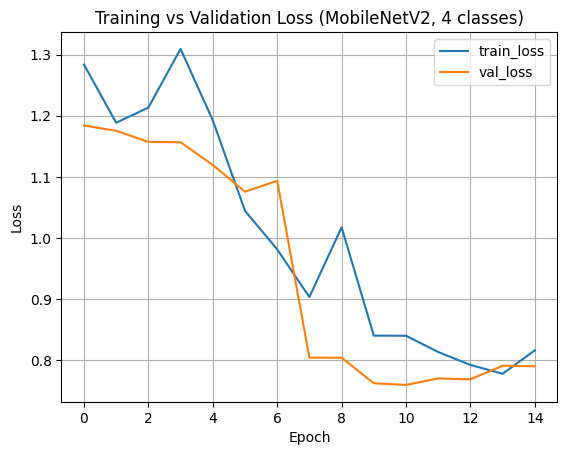

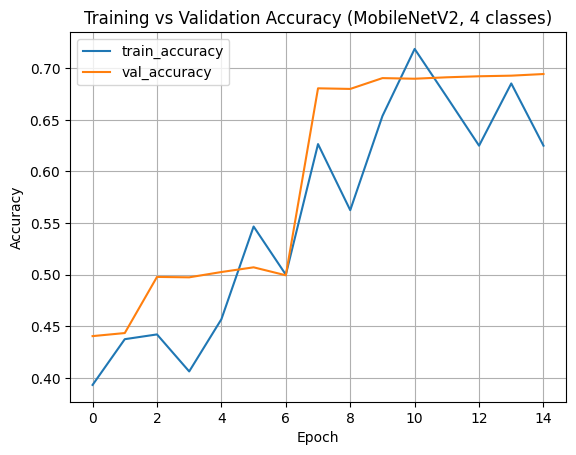

In [8]:
history = {}
for key in history_head.history.keys():
    history[key] = history_head.history[key] + history_ft.history[key]

# Графіки loss
plt.figure()
plt.plot(history['loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.title('Training vs Validation Loss (MobileNetV2, 4 classes)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Графіки accuracy
plt.figure()
plt.plot(history['accuracy'], label='train_accuracy')
plt.plot(history['val_accuracy'], label='val_accuracy')
plt.title('Training vs Validation Accuracy (MobileNetV2, 4 classes)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


## 8. Оцінка моделі на validation set
###    (accuracy, confusion matrix)

159/159 ━━━━━━━━━━━━━━━━━━━━ 75s 468ms/step
Validation accuracy (MobileNetV2, 4 classes): 0.6900688298918387
Classes: ['happy', 'neutral', 'sad', 'surprise']
Confusion matrix:
 [[1297  150  270   57]
 [  69  698  438   28]
 [  67  261  896   23]
 [  43   75   95  618]]


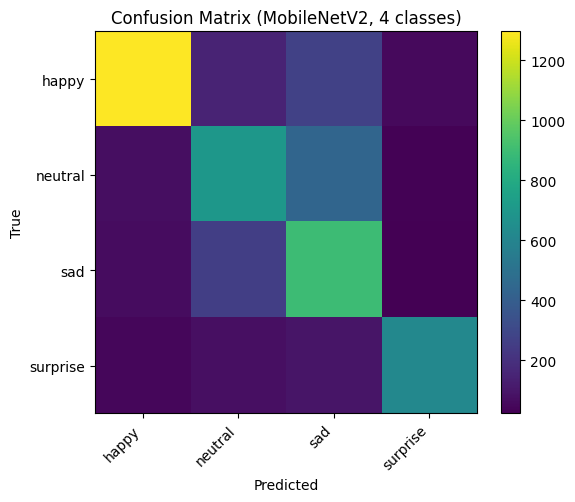

Classification report:
               precision    recall  f1-score   support

       happy     0.8787    0.7311    0.7982      1774
     neutral     0.5895    0.5661    0.5776      1233
         sad     0.5274    0.7185    0.6083      1247
    surprise     0.8512    0.7437    0.7938       831

    accuracy                         0.6901      5085
   macro avg     0.7117    0.6899    0.6945      5085
weighted avg     0.7179    0.6901    0.6974      5085



In [9]:
# Прогнози й істинні мітки
y_prob = model.predict(eval_generator)
y_pred = np.argmax(y_prob, axis=1)
y_true = eval_generator.classes

val_acc = accuracy_score(y_true, y_pred)
print("Validation accuracy (MobileNetV2, 4 classes):", val_acc)

# Імена класів
class_indices = eval_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print("Classes:", class_names)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest')
plt.colorbar(im)
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.title("Confusion Matrix (MobileNetV2, 4 classes)")
plt.tight_layout()
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification report:\n", report)